In [5]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Step 2: Load Dataset
df= pd.read_csv('mushroom.csv')
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [7]:
# Basic Exploration
print("Shape of the dataset:", df.shape)
print("Dataset Info:\n")
print(df.info())
print("\nClass Distribution:\n", df['class'].value_counts())

Shape of the dataset: (2000, 26)
Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_b

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
cap_shape,0
cap_surface,0
cap_color,0
bruises,0
odor,0
gill_attachment,0
gill_spacing,0
gill_size,0
gill_color,0


### Histogram: Distribution of Numerical Features

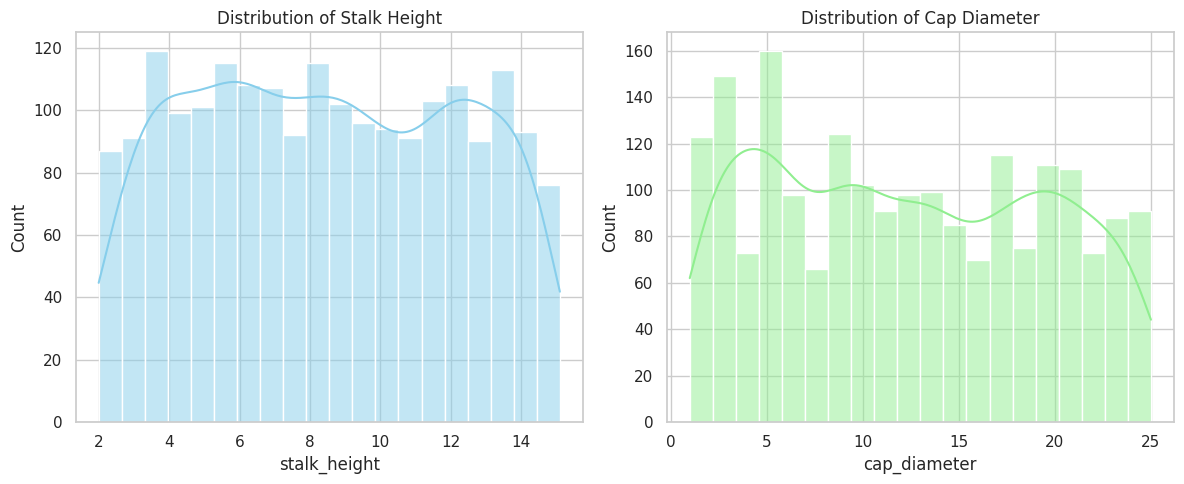

In [9]:
# Set plot style
sns.set(style="whitegrid")

# Plot histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['stalk_height'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Stalk Height')

plt.subplot(1, 2, 2)
sns.histplot(df['cap_diameter'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of Cap Diameter')

plt.tight_layout()
plt.show()

### Box Plots: To Spot Outliers

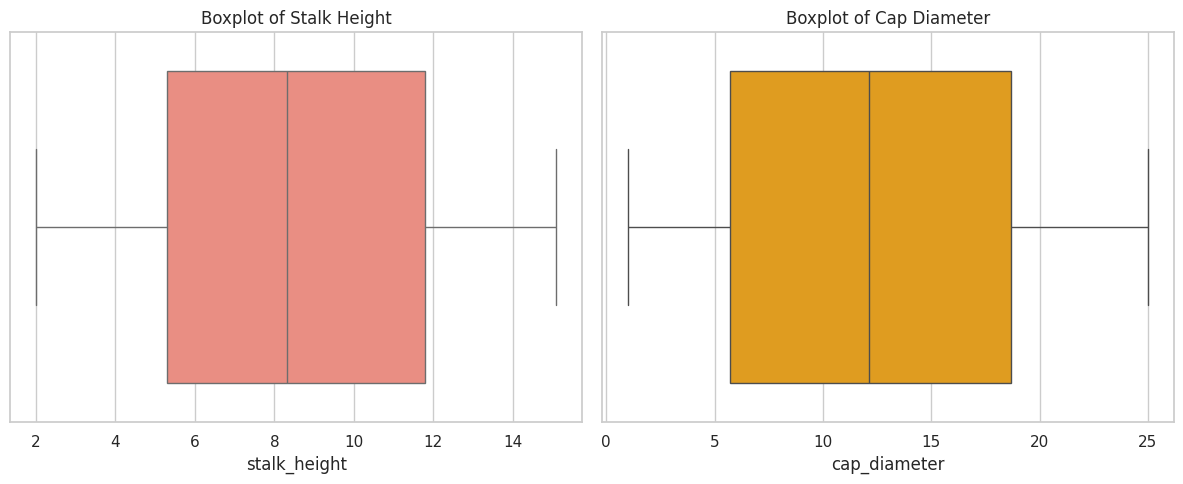

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['stalk_height'], color='salmon')
plt.title('Boxplot of Stalk Height')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['cap_diameter'], color='orange')
plt.title('Boxplot of Cap Diameter')

plt.tight_layout()
plt.show()

### Density Plots

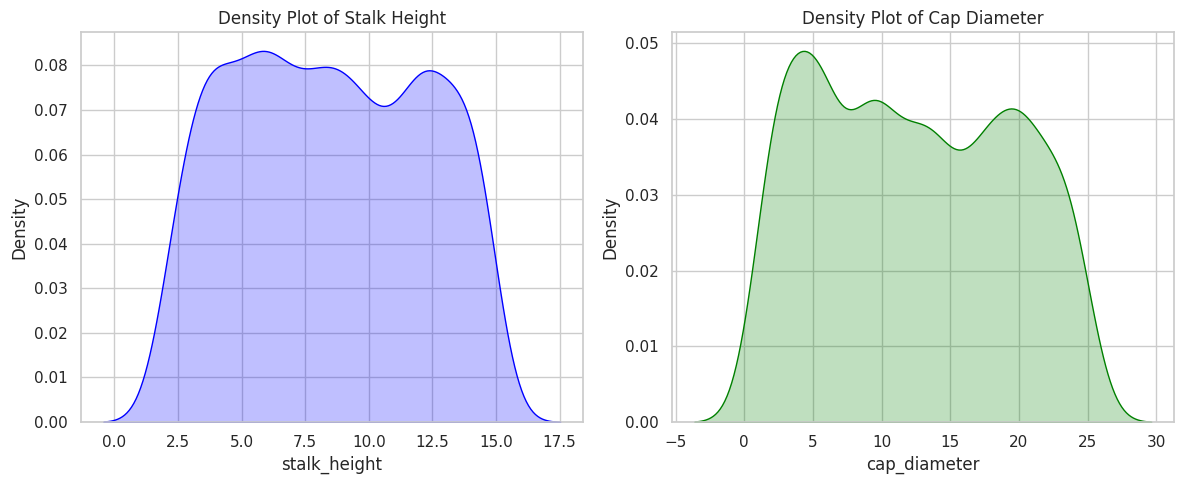

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(df['stalk_height'], shade=True, color='blue')
plt.title('Density Plot of Stalk Height')

plt.subplot(1, 2, 2)
sns.kdeplot(df['cap_diameter'], shade=True, color='green')
plt.title('Density Plot of Cap Diameter')

plt.tight_layout()
plt.show()

### Use correlation on numerical features

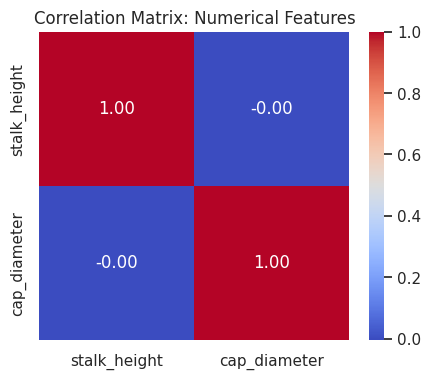

In [12]:
# Correlation matrix for numerical features
correlation_matrix = df[['stalk_height', 'cap_diameter']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Numerical Features')
plt.show()

In [13]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

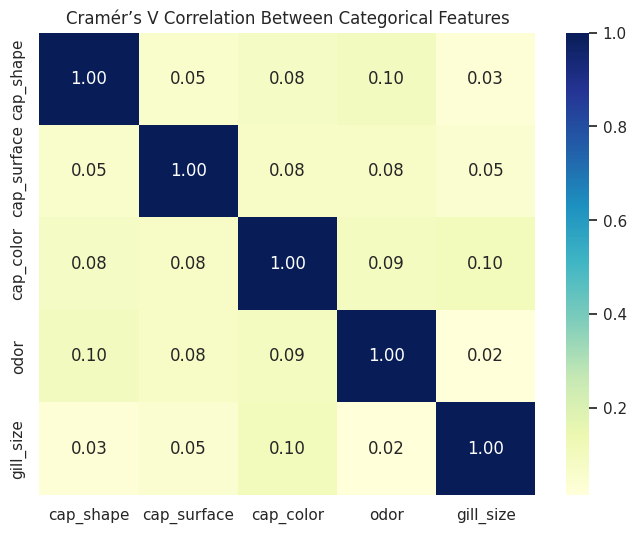

In [14]:
categorical_columns = ['cap_shape', 'cap_surface', 'cap_color', 'odor', 'gill_size']

cramers_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

for col1 in categorical_columns:
    for col2 in categorical_columns:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

# Heatmap for categorical feature correlations
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Cramér’s V Correlation Between Categorical Features")
plt.show()

# Task 2: Data Preprocessing

### Encode Categorical Variables

In [15]:
# Make a copy of the dataset
df_encoded = df.copy()

# Apply Label Encoding to all object (categorical) columns
label_encoders = {}
for column in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le  # Save encoders for inverse transform if needed

In [16]:
# Step 7: Split Data
x=df_encoded.drop('class', axis=1)## features
y= df['class'] ## Target
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 25)
(400, 25)
(1600,)
(400,)


# Task 3: Data Visualization

### Plot pairplot for the numeric features with hue as class

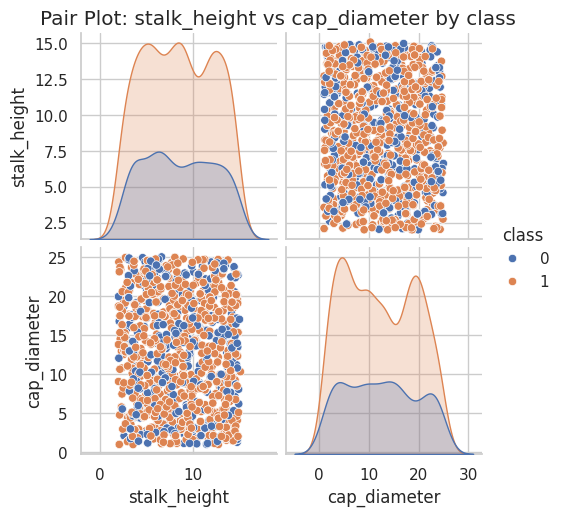

In [18]:
sns.pairplot(df_encoded[['stalk_height', 'cap_diameter', 'class']], hue='class')
plt.suptitle("Pair Plot: stalk_height vs cap_diameter by class", y=1.02)
plt.show()

### scatterplot

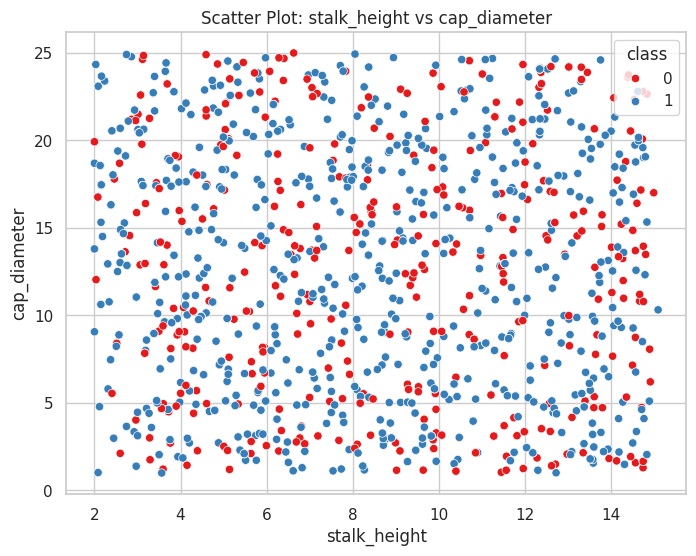

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_encoded, x='stalk_height', y='cap_diameter', hue='class', palette='Set1')
plt.title("Scatter Plot: stalk_height vs cap_diameter")
plt.show()

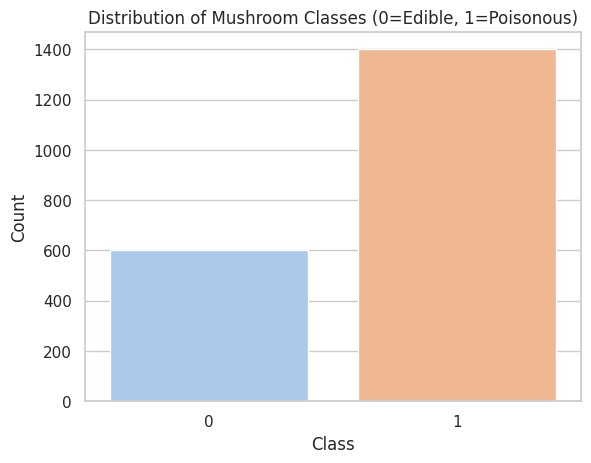

In [20]:
# Class distribution
sns.countplot(x='class', data=df_encoded, palette='pastel')
plt.title("Distribution of Mushroom Classes (0=Edible, 1=Poisonous)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [21]:
class_counts = df_encoded['class'].value_counts()
print("Class Distribution:\n", class_counts)

Class Distribution:
 class
1    1400
0     600
Name: count, dtype: int64


# Task 4: SVM Implementation

In [22]:
# Initialize the SVM model (default kernel is 'rbf')
svm_model = SVC()

In [23]:
# Train the model
svm_model.fit(x_train, y_train)

SVC()

In [24]:
# Predict on the test data
y_pred = svm_model.predict(x_test)

In [25]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
# Precision
precision = precision_score(y_test, y_pred, pos_label='poisonous')
# Recall
recall = recall_score(y_test, y_pred, pos_label='poisonous')
# F1-score
f1 = f1_score(y_test, y_pred, pos_label='poisonous')

In [26]:
# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.6675
Precision: 0.6675
Recall: 1.0000
F1 Score: 0.8006


In [27]:
# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

      edible       0.00      0.00      0.00       133
   poisonous       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400



# Task 5: Visualization of SVM Results

In [28]:
# Reduce to 2D for visualization using PCA
pca = PCA(n_components=2)
x_test_2D = pca.fit_transform(x_test)
x_test_2D

array([[-5.76721107e+02, -1.81513890e+00],
       [ 4.04271174e+02, -8.89389246e+00],
       [ 3.80283243e+02, -4.14737713e+00],
       [-5.81722825e+02, -4.45906762e+00],
       [-5.69715246e+02,  1.48370022e+00],
       [ 2.33283154e+02, -7.89725166e-01],
       [-4.59708255e+02,  7.18160073e+00],
       [ 2.82280876e+02, -5.03804901e+00],
       [-4.69701803e+02,  1.25293879e+01],
       [ 7.28450683e+00,  2.20635590e+00],
       [-2.69723747e+02, -9.34262927e+00],
       [-3.66726868e+02, -7.17053989e+00],
       [-7.07187944e+01,  1.13659360e+00],
       [-3.64710896e+02,  8.91649746e+00],
       [ 2.46273020e+02, -7.01864233e+00],
       [-5.40728514e+02, -7.01762656e+00],
       [ 2.51290865e+02,  3.97878606e+00],
       [ 4.58293800e+02,  9.17491672e+00],
       [ 2.85281954e+02,  4.67355372e+00],
       [ 4.12816794e+01, -4.51747049e-01],
       [ 5.32287822e+02,  9.34056797e+00],
       [-4.37724141e+02, -7.48020287e+00],
       [-2.56723844e+02, -6.67396325e+00],
       [ 4.

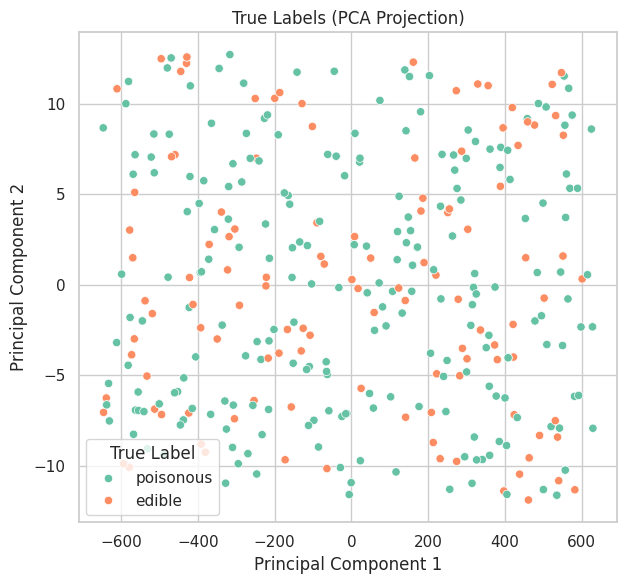

In [29]:
# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'PCA1': x_test_2D[:, 0],
    'PCA2': x_test_2D[:, 1],
    'True Label': y_test,
    'Predicted Label': y_pred
})

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='True Label', palette='Set2')
plt.title('True Labels (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

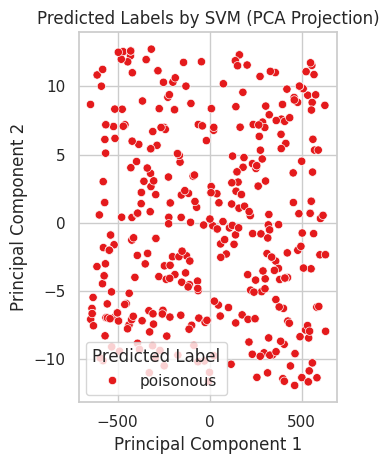

In [30]:
# Predicted labels
plt.subplot(1, 2, 2)
sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='Predicted Label', palette='Set1')
plt.title('Predicted Labels by SVM (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

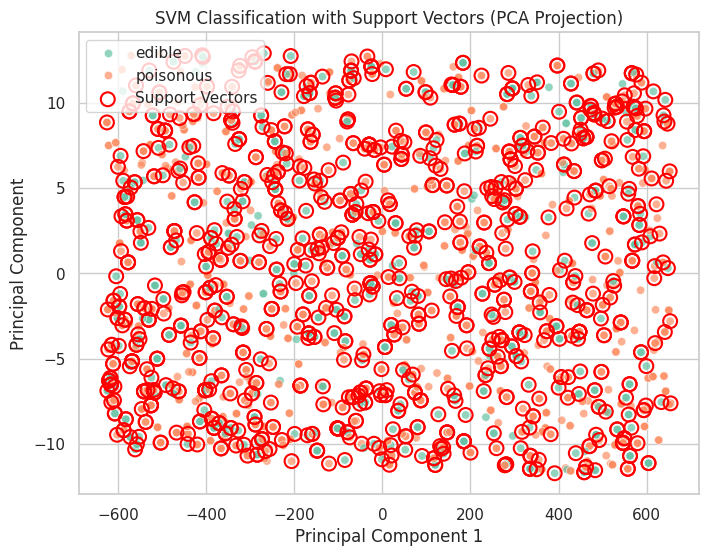

In [31]:
# Reduce entire dataset to 2D for visualization
x_all = pd.concat([x_train, x_test])
x_all_2D = PCA(n_components=2).fit_transform(x_all)

# Map the full labels (including support vectors) to PCA
svm_model.fit(x_train, y_train)  # Ensure the model is trained
support_vectors = svm_model.support_  # indices of support vectors in training set

# Prepare dataframe for all points
full_df = pd.DataFrame({
    'PCA1': x_all_2D[:, 0],
    'PCA2': x_all_2D[:, 1],
    'Label': pd.concat([y_train, y_test]).values
})

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=full_df, x='PCA1', y='PCA2', hue='Label', palette='Set2', alpha=0.7)

# Overlay support vectors (only from training set)
plt.scatter(
    x_all_2D[support_vectors, 0],
    x_all_2D[support_vectors, 1],
    s=100, facecolors='none', edgecolors='red', linewidths=1.5,
    label='Support Vectors'
)

plt.title('SVM Classification with Support Vectors (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component')
plt.legend()
plt.grid(True)
plt.show()

# Task 6: Parameter Tuning and Optimization

In [42]:
# Define parameter grid
param_grid = {
    'C': [1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale']
}

In [43]:
grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2  # optional: shows progress
)

In [44]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [1, 10], 'gamma': ['scale'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy', verbose=2)

In [45]:
# Display best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy: 0.7081250000000001


In [46]:
# Evaluate best model on the test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(x_test)

In [47]:
# Classification report
print("\nClassification Report on Test Set:\n", classification_report(y_test, y_pred_best))


Classification Report on Test Set:
               precision    recall  f1-score   support

      edible       0.00      0.00      0.00       133
   poisonous       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400



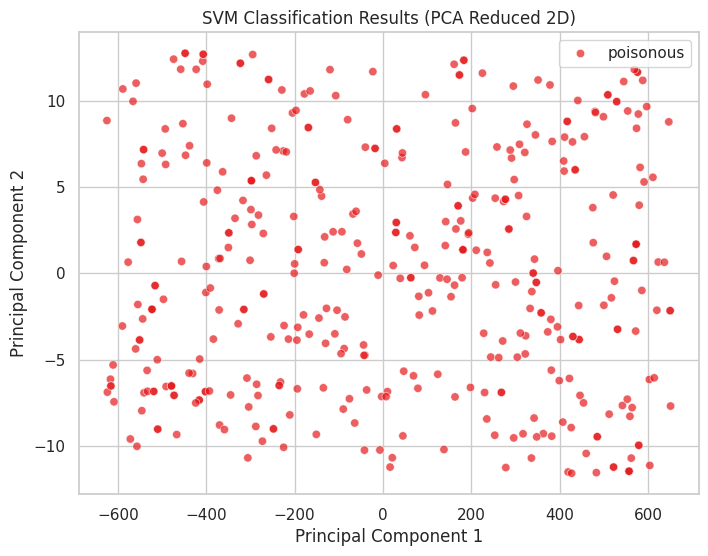

In [49]:
# PCA for 2D Visualization
pca = PCA(n_components=2)
x_reduced = pca.fit_transform(x)

x_train_pca, x_test_pca, y_train_pca, y_test_pca = train_test_split(x_reduced, y, test_size=0.2, random_state=42)
svm_pca = SVC(kernel='rbf')
svm_pca.fit(x_train_pca, y_train_pca)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_test_pca[:, 0], y=x_test_pca[:, 1],
                hue=svm_pca.predict(x_test_pca), palette='Set1', alpha=0.7)
plt.title("SVM Classification Results (PCA Reduced 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
- Linear - Performs well with large number of features and linearly separable data
- RBF - Captures complex patterns, works better for non-linear decision boundaries
- Poly - Can model non-linearities, but slower and may overfit on small datasets
  
2.	Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.
- Strengths:
- Handles high-dimensional data well: Most features are categorical and one-hot encoded, increasing dimensionality.
- Effective in finding clear class boundaries: SVM maximizes margin between classes important for datasets like mushrooms, where the difference between edible and poisonous is critical.
- Good performance with RBF kernel: Captures non-linear relations among categorical and numerical features.

-  Weaknesses:
-  Training time can be high with large datasets or many hyperparameter combinations.
-  Doesn’t scale well to millions of records unless using approximate methods.
-  Sensitive to choice of kernel and parameters, requiring tuning like C, gamma, and kernel type.
-  Interpretability: Harder to interpret than decision trees or logistic regression.
  
3.	Discuss practical implications of SVM in real-world classification tasks.
- Bioinformatics / Medical: Mushroom edibility prediction mimics use cases in medical diagnosis (e.g., benign vs. malignant)
- Security: SVMs are used in intrusion detection, spam filtering, and fraud detection.
- Text Classification: High-dimensional sparse data (like NLP) is well-handled by SVM.
- Legal / Sensitive decisions: Since SVMs are not easily interpretable, they may not be preferred where explainability is required (e.g., credit scoring, legal decisions).